In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [8]:
DATA_PATH = "shopping_behavior_updated (1).csv"
df = pd.read_csv(DATA_PATH)

df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


In [10]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (3900, 16)

Missing values per column:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [12]:
target_col = "Subscription Status"
df[target_col].value_counts()

,count
Subscription Status,
No,2847
Yes,1053


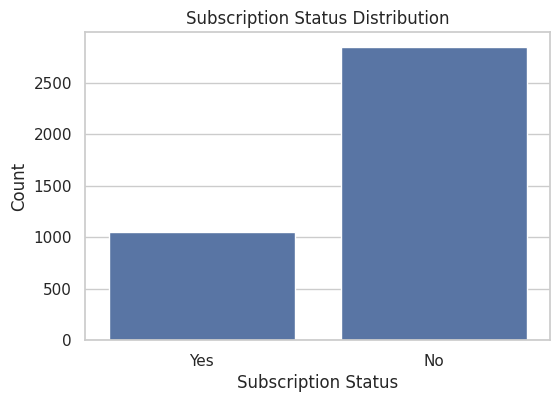

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Subscription Status Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Count")
plt.show()

In [16]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


In [18]:
df_fe = df.copy()

df_fe["is_winter"] = (df_fe["Season"] == "Winter").astype(int)

df_fe["is_senior"] = (df_fe["Age"] > 60).astype(int)

df_fe["is_high_spend"] = (df_fe["Purchase Amount (USD)"] > 80).astype(int)

df_fe[["Season", "is_winter", "Age", "is_senior", "Purchase Amount (USD)", "is_high_spend"]].head(10)

,Season,is_winter,Age,is_senior,Purchase Amount (USD),is_high_spend
0,Winter,1,55,0,53,0
1,Winter,1,19,0,64,0
2,Spring,0,50,0,73,0
3,Spring,0,21,0,90,1
4,Spring,0,45,0,49,0
5,Summer,0,46,0,20,0
6,Fall,0,63,1,85,1
7,Winter,1,27,0,34,0
8,Summer,0,26,0,97,1
9,Spring,0,57,0,31,0


In [20]:
df_fe["price_per_previous_purchase"] = df_fe["Purchase Amount (USD)"] / df_fe["Previous Purchases"]
df_fe[["Previous Purchases", "Purchase Amount (USD)", "price_per_previous_purchase"]].head(10)

,Previous Purchases,Purchase Amount (USD),price_per_previous_purchase
0,14,53,3.785714
1,2,64,32.000000
2,23,73,3.173913
3,49,90,1.836735
4,31,49,1.580645
5,14,20,1.428571
6,49,85,1.734694
7,19,34,1.789474
8,8,97,12.125000
9,4,31,7.750000


In [23]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found in Shopping dataset. Skipping Haversine feature.")

Coordinate columns not found in Shopping dataset. Skipping Haversine feature.


In [25]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")


Item_Name column not found.


In [27]:
df_fe["price_tier"] = pd.cut(
    df_fe["Purchase Amount (USD)"],
    bins=[0, 40, 70, 90, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Purchase Amount (USD)","price_tier"]].head(10)

,Purchase Amount (USD),price_tier
0,53,medium
1,64,medium
2,73,high
3,90,high
4,49,medium
5,20,low
6,85,high
7,34,low
8,97,very_high
9,31,low


In [29]:
drop_cols = [
    "Customer ID",
    "Item Purchased"  # we replaced it with Item_Name_reduced
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (3900, 18)
y shape: (3900,)


,Age,Gender,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,is_winter,is_senior,is_high_spend,price_per_previous_purchase,price_tier
0,55,Male,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,14,Venmo,Fortnightly,1,0,0,3.785714,medium
1,19,Male,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,2,Cash,Fortnightly,1,0,0,32.000000,medium
2,50,Male,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,23,Credit Card,Weekly,0,0,0,3.173913,high
3,21,Male,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,49,PayPal,Weekly,0,0,1,1.836735,high
4,45,Male,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,31,PayPal,Annually,0,0,0,1.580645,medium


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3120, 18)
Test size: (780, 18)


In [34]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns: ['Gender', 'Category', 'Location', 'Size', 'Color', 'Season', 'Discount Applied', 'Payment Method', 'Frequency of Purchases', 'price_tier']
Numeric columns: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'is_winter', 'is_senior', 'is_high_spend', 'price_per_previous_purchase']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Category',
                                                   'Location', 'Size', 'Color',
                                                   'Season', 'Discount Applied',
                                                   'Payment Method',
                                                   'Frequency of Purchases',
                                                   'price_tier']),
                                                 ('num', 'passthrough',
                                                  ['Age',
                                                   'Purchase Amount (USD)',
                                                   'Review Rating',
                                                   'Previous Purchases',
                                                   'is_winter', 'is_senior',
                                                   'is_high_spend',
                                                   'price_per_previous_purchase'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [47]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report: ")
print(classification_report(y_test, y_pred))
print("# Clarification: Yes & No in this previous section is a classification of Subscription Status (if a customer has an active subscription with the store or not)")


Accuracy: 0.8436

Classification Report: 
              precision    recall  f1-score   support

          No       0.94      0.84      0.89       569
         Yes       0.66      0.86      0.75       211

    accuracy                           0.84       780
   macro avg       0.80      0.85      0.82       780
weighted avg       0.87      0.84      0.85       780

# Clarification: Yes & No in this previous section is a classification of Subscription Status (if a customer has an active subscription with the store or not)


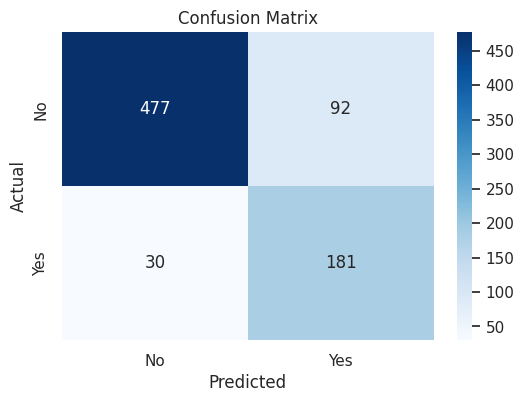

In [49]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
90,Discount Applied_Yes,0.248272
89,Discount Applied_No,0.231334
1,Gender_Male,0.064643
0,Gender_Female,0.053448
115,price_per_previous_purchase,0.031672
108,Age,0.028593
109,Purchase Amount (USD),0.027326
111,Previous Purchases,0.026492
110,Review Rating,0.024724
3,Category_Clothing,0.005470


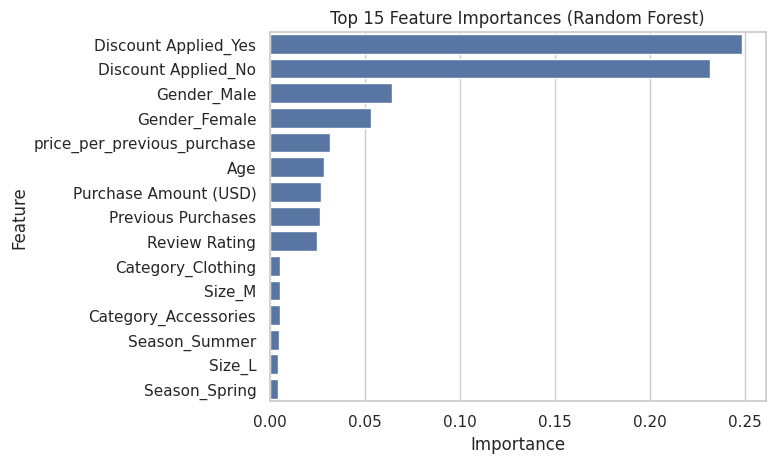

In [53]:
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [57]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))
print("# Clarification: Yes & No in this previous section is a classification of Subscription Status (if a customer has an active subscription with the store or not)")


Accuracy (with feature selection): 0.8423

Classification Report (with feature selection):
              precision    recall  f1-score   support

          No       0.92      0.86      0.89       569
         Yes       0.68      0.80      0.73       211

    accuracy                           0.84       780
   macro avg       0.80      0.83      0.81       780
weighted avg       0.85      0.84      0.85       780

# Clarification: Yes & No in this previous section is a classification of Subscription Status (if a customer has an active subscription with the store or not)
